# 02. State 이해

---

## State란?

`State`는 그래프 실행 중 유지되는 **공유 상태 객체**를 의미한다.

각 노드는 현재 State를 입력으로 받고, 변경할 값만 딕셔너리로 반환한다.  
LangGraph는 노드가 반환한 값을 기존 State에 병합하여 다음 노드로 전달한다.

```text
             ┌──────────────┐
  NodeA ────→│    State     │←──── NodeC
             │ {key: value} │
  NodeB ────→│  (공유 상태)│←──── NodeD
             └──────────────┘
```

## State 업데이트 규칙

노드가 딕셔너리를 반환하면 LangGraph가 **기존 State에 병합**한다.

```python
# 현재 State:  {"a": 1, "b": 2, "c": 3}
# 노드 반환값: {"b": 99}
# 병합 결과:   {"a": 1, "b": 99, "c": 3}  ← b만 업데이트
```

## State를 설계하는 3가지 대표 방식

| 방식 | 업데이트 방식 | 용도 |
|---|---|---|
| 기본 `TypedDict` | 같은 key는 새 값으로 덮어쓰기 | 일반 데이터 관리 |
| `Annotated + reducer` | 기존 값과 새 값을 reducer 함수로 병합 | 로그, 리스트, 누적 결과 |
| `MessagesState` | `messages` 필드를 `add_messages` reducer로 관리 | 챗봇·대화 이력 |

## 환경변수 로딩

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

True

---

## 1. 기본 State - 덮어쓰기(Overwrite)
`name`은 노드에서 직접 수정하지 않지만 최종 State에 그대로 유지된다.  
즉, 노드가 반환하지 않은 key는 기존 값이 유지된다.

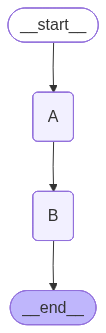

  [NodeA] 입력: count=0
  [NodeB] 입력: count=1

최종 State: {'name': '홍길동', 'count': 11, 'message': 'B 실행 완료'}
→ count는 0 → 1 → 11 로 순서대로 덮어씌워짐


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 기본 State: 새 값이 이전 값을 덮어씀
class BasicState(TypedDict):
    name: str
    count: int
    message: str

def node_a(state: BasicState) -> dict:
    print(f"  [NodeA] 입력: count={state['count']}")
    return {"count": state["count"] + 1, "message": "A 실행 완료"}

def node_b(state: BasicState) -> dict:
    print(f"  [NodeB] 입력: count={state['count']}")
    return {"count": state["count"] + 10, "message": "B 실행 완료"}

builder = StateGraph(BasicState)
builder.add_node("A", node_a)
builder.add_node("B", node_b)
builder.add_edge(START, "A")
builder.add_edge("A", "B")
builder.add_edge("B", END)
app = builder.compile()

# 그래프 시각화
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Mermaid 이미지 생성 실패: {e}")
    print(app.get_graph().draw_ascii())

result = app.invoke({"name": "홍길동", "count": 0, "message": ""})
print(f"\n최종 State: {result}")
print("→ count는 0 → 1 → 11 로 순서대로 덮어씌워짐")

---

## 2. Annotated + Reducer - 누적(Accumulate)

기본 State는 값을 **덮어씁니다**. 하지만 리스트를 **누적**하려면 Reducer를 사용한다.

```python
# Reducer 없음 (덮어쓰기)
# 현재: ["A"]   노드 반환: ["B"]   결과: ["B"]

# Reducer 있음 (누적)
# 현재: ["A"]   노드 반환: ["B"]   결과: ["A", "B"]
```

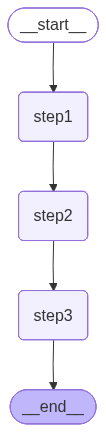


최종 State: {'history': ['step1 실행', 'step2 실행', 'step3 실행'], 'total': 3}
history 누적: ['step1 실행', 'step2 실행', 'step3 실행']  ← 3개 모두 쌓임
total 덮어쓰기: 3  ← 마지막 값만


In [ ]:
import operator
from typing import Annotated

class AccumulateState(TypedDict):
    # Annotated[타입, reducer함수] → 반환값을 기존 값에 더함
    history: Annotated[list[str], operator.add]    # 리스트 누적
    total: int                             # 일반 덮어쓰기

def step1(state: AccumulateState) -> dict:
    return {"history": ["step1 실행"], "total": 1}

def step2(state: AccumulateState) -> dict:
    return {"history": ["step2 실행"], "total": 2}

def step3(state: AccumulateState) -> dict:
    return {"history": ["step3 실행"], "total": 3}

builder = StateGraph(AccumulateState)
builder.add_node("step1", step1)
builder.add_node("step2", step2)
builder.add_node("step3", step3)

builder.add_edge(START, "step1")
builder.add_edge("step1", "step2")
builder.add_edge("step2", "step3")
builder.add_edge("step3", END)
graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Mermaid 이미지 생성 실패: {e}")
    print(graph.get_graph().draw_ascii())

result = graph.invoke({"history": [], "total": 0})
print(f"\n최종 State: {result}")
print(f"history 누적: {result['history']}  ← 3개 모두 쌓임")
print(f"total 덮어쓰기: {result['total']}  ← 마지막 값만")

---

## 3. MessagesState - 대화 메시지 관리

`MessagesState`는 LangGraph가 제공하는 메시지 관리용 prebuilt State이다.

내부적으로 `messages` 필드에 `add_messages` reducer가 적용되어 있어,
새 메시지는 기존 메시지 뒤에 추가된다.
또한 같은 `id`를 가진 메시지가 들어오면 기존 메시지를 교체할 수 있다.

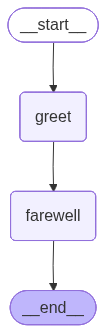


[대화 기록 전체]
  사용자: 반갑습니다
  AI: 안녕하세요! '반갑습니다'라고 하셨군요.
  AI: 감사합니다. 좋은 하루 되세요!


In [ ]:
from langgraph.graph import MessagesState
from langchain.messages import HumanMessage, AIMessage

# MessagesState 내부 구조
# class MessagesState(TypedDict):
#     messages: Annotated[list[BaseMessage], add_messages]
# → add_messages reducer: 새 메시지는 추가, 같은 id면 업데이트

def greet(state: MessagesState) -> dict:
    user_msg = state["messages"][-1].content  # 마지막 메시지
    return {
        "messages": [AIMessage(content=f"안녕하세요! '{user_msg}'라고 하셨군요.")]
    }

def farewell(state: MessagesState) -> dict:
    return {
        "messages": [AIMessage(content="감사합니다. 좋은 하루 되세요!")]
    }

builder = StateGraph(MessagesState)
builder.add_node("greet", greet)
builder.add_node("farewell", farewell)

builder.add_edge(START, "greet")
builder.add_edge("greet", "farewell")
builder.add_edge("farewell", END)
graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Mermaid 이미지 생성 실패: {e}")
    print(graph.get_graph().draw_ascii())

result = graph.invoke({
    "messages": [HumanMessage(content="반갑습니다")]
})

print("\n[대화 기록 전체]")
for msg in result["messages"]:
    role = "사용자" if isinstance(msg, HumanMessage) else "AI"
    print(f"  {role}: {msg.content}")

---

## 4. State 비교 정리

In [5]:
# 실습: 세 가지 State 방식의 차이를 직접 비교

print("=" * 50)
print("State 업데이트 방식 비교")
print("=" * 50)

# 1. 기본 덮어쓰기
class S1(TypedDict):
    items: list[str]  # 새 값이 기존 값을 덮어씀

# 2. Annotated 누적
class S2(TypedDict):
    items: Annotated[list[str], operator.add]

def add_item(state) -> dict:
    return {"items": ["new_item"]}

for State, name in [(S1, "덮어쓰기"), (S2, "누적(Annotated)")]:
    b = StateGraph(State)
    b.add_node("add", add_item)
    b.add_edge(START, "add")
    b.add_edge("add", END)
    a = b.compile()
    r = a.invoke({"items": ["existing_item"]})
    print(f"\n[{name}]")
    print(f"  초기: ['existing_item']")
    print(f"  결과: {r['items']}")

State 업데이트 방식 비교

[덮어쓰기]
  초기: ['existing_item']
  결과: ['new_item']

[누적(Annotated)]
  초기: ['existing_item']
  결과: ['existing_item', 'new_item']


---

## 정리

```python
# 1. 기본 TypedDict → 덮어쓰기
class State(TypedDict):
    value: int

# 2. Annotated + operator.add → 리스트 누적
class State(TypedDict):
    logs: Annotated[list[str], operator.add]

# 3. MessagesState → 대화 메시지 자동 관리 (내장)
from langgraph.graph import MessagesState
```
